In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amirmahdiabbootalebi/heart-disease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease' dataset.
Path to dataset files: /kaggle/input/heart-disease


In [ ]:
import pandas as pd
import os

# List files in the downloaded path to identify the CSV file
file_list = os.listdir(path)
print(f"Files in the dataset directory: {file_list}")

# Assuming the CSV file is named 'Heart Disease.csv' or similar, let's find it.
csv_file = [f for f in file_list if f.endswith('.csv')][0] # Take the first CSV file found
full_csv_path = os.path.join(path, csv_file)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(full_csv_path)

Files in the dataset directory: ['heart.csv']


In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Remove rows with any missing values
df_cleaned = df.dropna()

# Display the first 5 rows of the DataFrame after dropping missing values
display(df_cleaned.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Explanation of the code:

*   `df_cleaned = df.dropna()`:
    *   `df` refers to your original DataFrame.
    *   `.dropna()` is a pandas DataFrame method that removes rows (by default) that contain any `NaN` (Not a Number) or missing values.
    *   The result, which is a new DataFrame with missing values removed, is assigned to a new variable `df_cleaned`.
*   `display(df_cleaned.head())`:
    *   `df_cleaned.head()` returns the first 5 rows of the `df_cleaned` DataFrame.
    *   `display()` is used to render the DataFrame nicely in the Colab output.

In [ ]:
print("Original data types:")
print(df_cleaned.dtypes)

categorical_cols_to_encode = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Check if these columns exist in the DataFrame and are of object/category dtype
actual_categorical_cols = [col for col in categorical_cols_to_encode if col in df_cleaned.columns and df_cleaned[col].dtype == 'object']

if not actual_categorical_cols:
    print("\nNo text/categorical columns found among the specified list for one-hot encoding. You can skip this step.")
else:
    print(f"\nApplying one-hot encoding to columns: {actual_categorical_cols}")
    df_encoded = pd.get_dummies(df_cleaned, columns=actual_categorical_cols, drop_first=False) # drop_first=False to keep all dummy variables

    print("\nDataFrame after one-hot encoding (first 5 rows):")
    display(df_encoded.head())

    # Optionally, to show just the new columns and how they relate to the original
    print("\nNewly created dummy columns:")
    new_dummy_cols = [col for col in df_encoded.columns if any(cat_col + '_' in col for cat_col in actual_categorical_cols) and col not in df_cleaned.columns]
    print(new_dummy_cols)

Original data types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Applying one-hot encoding to columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

DataFrame after one-hot encoding (first 5 rows):


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True



Newly created dummy columns:
['Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


### Data Distribution: Histograms of All Features

Let's visualize the distribution of all features in the `df_encoded` DataFrame using histograms. This will help us understand the spread, skewness, and potential outliers in each feature.

/tmp/ipykernel_5192/630653944.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_encoded[column], kde=True, bins=20, palette='viridis')
/tmp/ipykernel_5192/630653944.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_encoded[column], kde=True, bins=20, palette='viridis')
/tmp/ipykernel_5192/630653944.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_encoded[column], kde=True, bins=20, palette='viridis')
/tmp/ipykernel_5192/630653944.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_encoded[column], kde=True, bins=20, palette='viridis')
/tmp/ipykernel_5192/630653944.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_encoded[column], kde=True, bins=20, palette='viridis')
/tmp/ipykernel_5192/630653944.py:19: UserWarning: Ignoring `palet

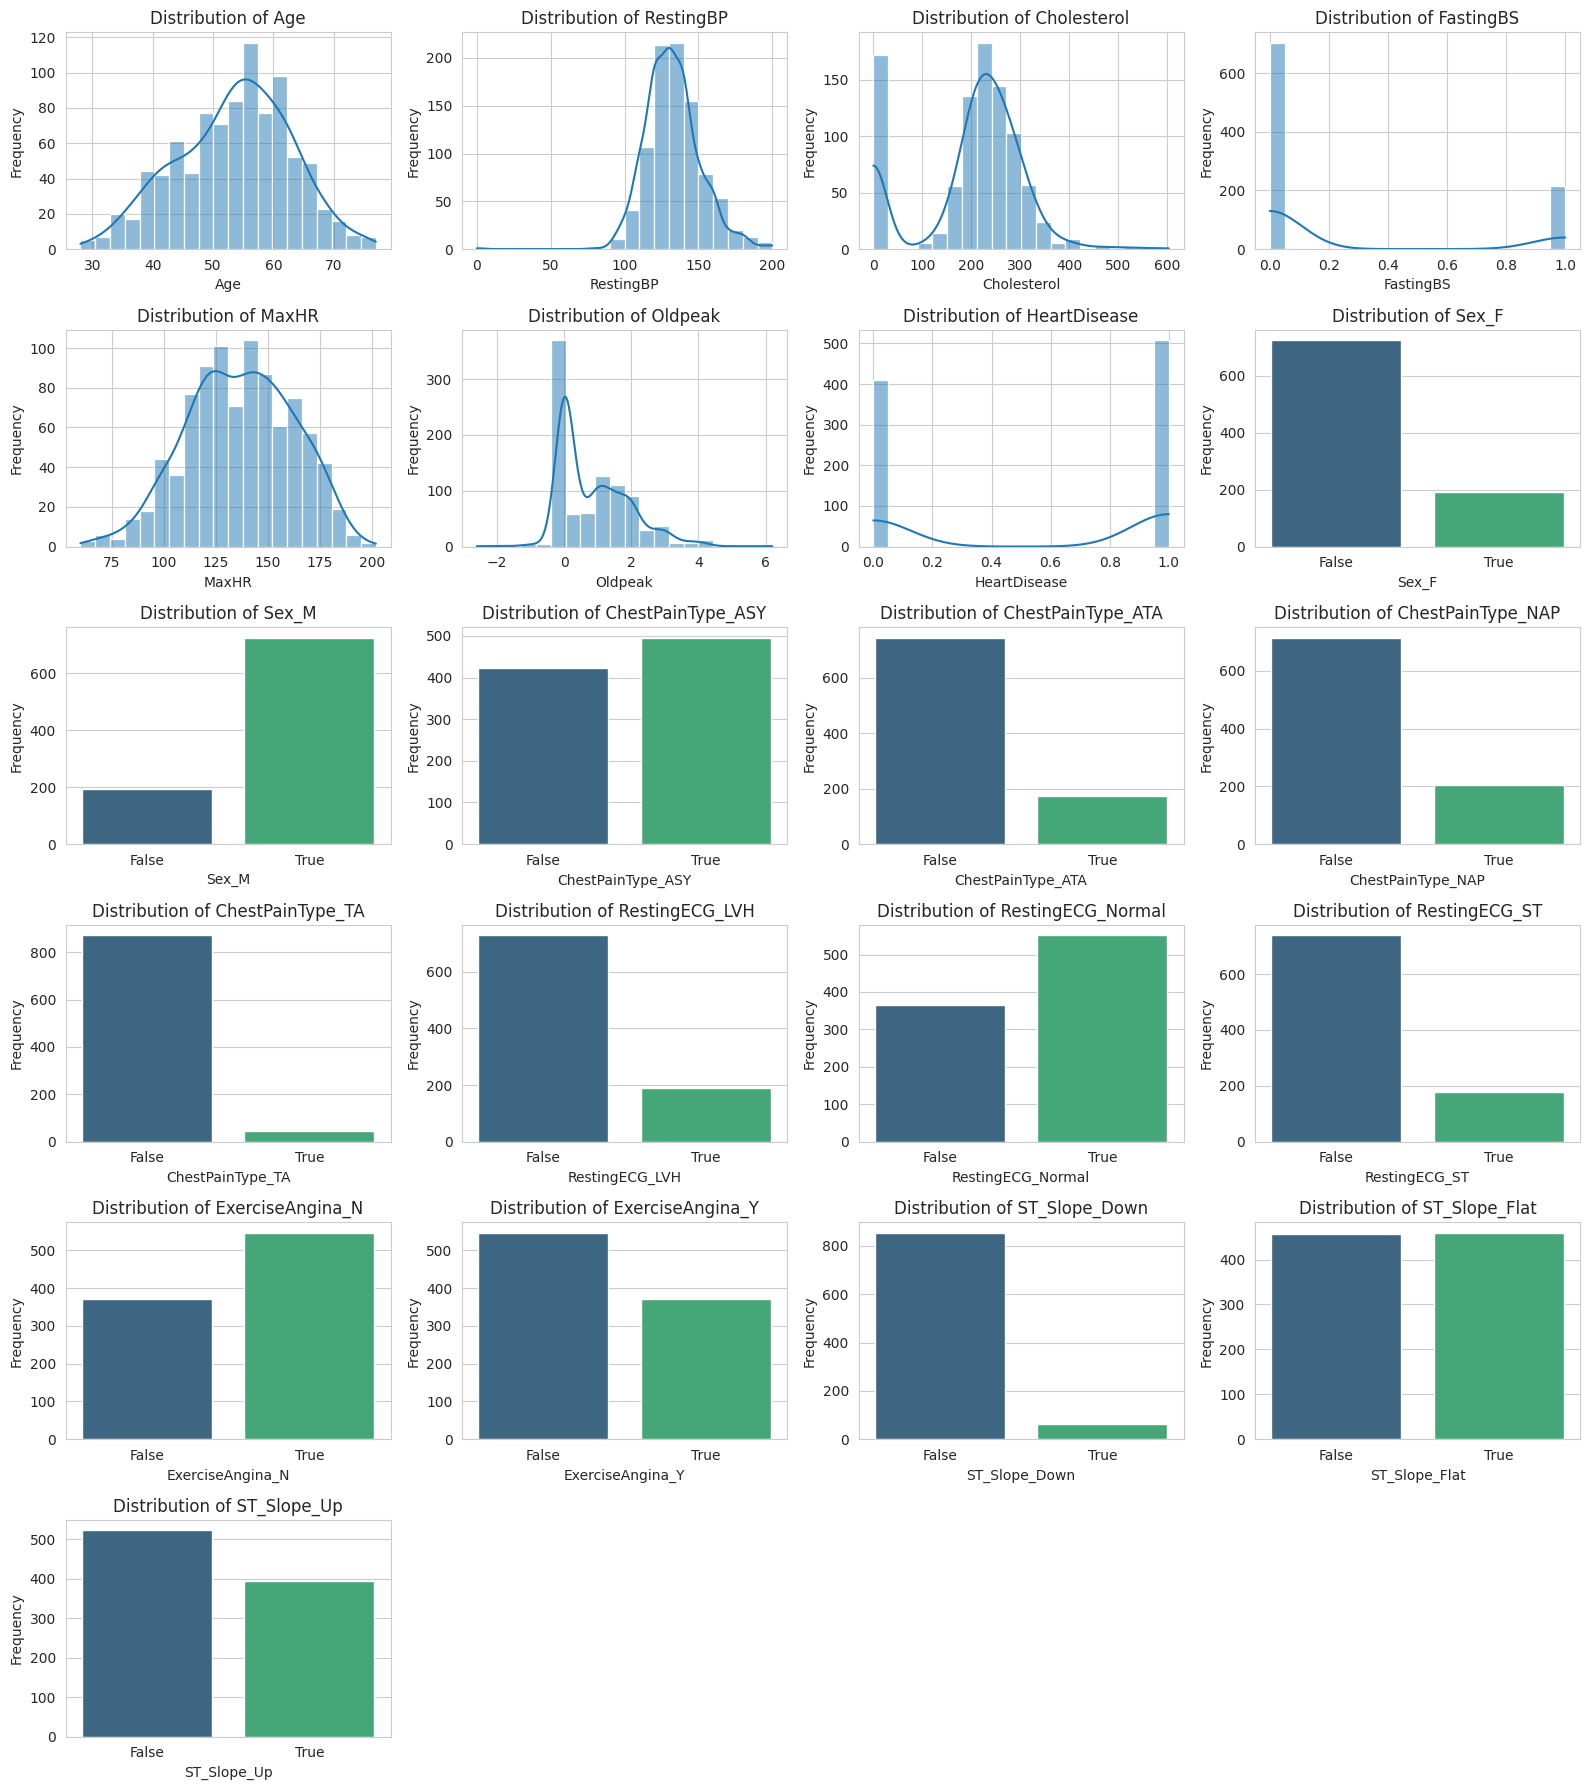

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Determine the number of columns and rows for the subplot grid
num_features = df_encoded.shape[1]
num_cols = 4  # You can adjust this number based on how many columns you want per row
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 4, num_rows * 3)) # Adjust figure size dynamically

for i, column in enumerate(df_encoded.columns):
    plt.subplot(num_rows, num_cols, i + 1) # Create a subplot for each feature
    if df_encoded[column].dtype == 'bool': # Handle boolean columns specifically
        sns.countplot(x=column, data=df_encoded, palette='viridis')
    else:
        sns.histplot(df_encoded[column], kde=True, bins=20, palette='viridis')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [ ]:
# Define the target column
target_column = 'HeartDisease'

# Create the feature matrix X by dropping the target column
X = df_encoded.drop(columns=[target_column])

# Create the target vector y
y = df_encoded[target_column]

# Print the shapes of X and y
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (918, 20)
Shape of y (target): (918,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the features and transform them
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame for easier inspection, retaining column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the scaled features
print("Scaled features (X_scaled) head:")
display(X_scaled.head())

Scaled features (X_scaled) head:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432,-0.515952,0.515952,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.823556,-0.823556,-0.271448,-1.002181,1.150674
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664,1.938163,-1.938163,-1.084138,-0.481887,1.876744,-0.229679,-0.507478,0.814275,-0.490449,0.823556,-0.823556,-0.271448,0.997824,-0.869056
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432,-0.515952,0.515952,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,-1.228087,2.038947,0.823556,-0.823556,-0.271448,-1.002181,1.150674
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711,1.938163,-1.938163,0.922392,-0.481887,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,-1.214246,1.214246,-0.271448,0.997824,-0.869056
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432,-0.515952,0.515952,-1.084138,-0.481887,1.876744,-0.229679,-0.507478,0.814275,-0.490449,0.823556,-0.823556,-0.271448,-1.002181,1.150674


In [ ]:
from sklearn.model_selection import train_test_split
import torch

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Convert arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) # unsqueeze for binary classification target
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print(f"\nShape of X_train_tensor: {X_train_tensor.shape}")
print(f"Shape of X_test_tensor: {X_test_tensor.shape}")
print(f"Shape of y_train_tensor: {y_train_tensor.shape}")
print(f"Shape of y_test_tensor: {y_test_tensor.shape}")

Shape of X_train: (734, 20)
Shape of X_test: (184, 20)
Shape of y_train: (734,)
Shape of y_test: (184,)

Shape of X_train_tensor: torch.Size([734, 20])
Shape of X_test_tensor: torch.Size([184, 20])
Shape of y_train_tensor: torch.Size([734, 1])
Shape of y_test_tensor: torch.Size([184, 1])


We keep a separate test set that the model never trains on to provide an unbiased evaluation of the model's performance on new, unseen data, ensuring its ability to generalize rather than just memorize the training examples.

In [ ]:
import torch.nn as nn

# Define the neural network architecture
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        # First hidden layer: takes input_size features and outputs 32 features
        self.fc1 = nn.Linear(input_size, 32)
        # ReLU activation function for the first hidden layer
        self.relu1 = nn.ReLU()
        # Dropout layer with a probability of 0.2
        self.dropout = nn.Dropout(0.2)
        # Second hidden layer: takes 32 features and outputs 16 features
        self.fc2 = nn.Linear(32, 16)
        # ReLU activation function for the second hidden layer
        self.relu2 = nn.ReLU()
        # Output layer: takes 16 features and outputs 1 feature (for binary classification)
        self.fc3 = nn.Linear(16, 1)
        # Sigmoid activation function for the output layer (to produce probabilities between 0 and 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass input through the first fully connected layer
        x = self.fc1(x)
        # Apply ReLU activation
        x = self.relu1(x)
        # Apply dropout
        x = self.dropout(x)
        # Pass through the second fully connected layer
        x = self.fc2(x)
        # Apply ReLU activation
        x = self.relu2(x)
        # Pass through the output layer
        x = self.fc3(x)
        # Apply Sigmoid activation to get the final output
        x = self.sigmoid(x)
        return x

# Instantiate the model with the correct input size (number of features in X_train_tensor)
# X_train_tensor.shape[1] gives the number of features
input_features = X_train_tensor.shape[1]
model = NeuralNetwork(input_features)

# Print the model architecture to verify
print(model)

NeuralNetwork(
  (fc1): Linear(in_features=20, out_features=32, bias=True)
  (relu1): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
import torch.optim as optim

# Define the loss function (Binary Cross Entropy with Logits Loss is often used for binary classification
# with a sigmoid output, it combines sigmoid and BCE for numerical stability).
# Since our model's last layer is Sigmoid, we will use BCELoss.
loss_function = nn.BCELoss()

# Define the optimizer (Adam optimizer with a learning rate of 0.01)
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Loss function and optimizer have been set up.")

Loss function and optimizer have been set up.


### Explanation of Loss Function and Optimizer:

*   **Loss Function (`nn.BCELoss()` in this case):** In simple terms, the loss function measures how well your model is doing. It calculates the difference between what your model predicts and the actual correct answer. A smaller loss value means the model's prediction is closer to the true value, indicating better performance.

*   **Optimizer (`optim.Adam()` in this case):** The optimizer is like the 'teacher' for your neural network. Its job is to adjust the internal settings (weights and biases) of the network based on the feedback from the loss function. It tries to minimize the loss, guiding the model to learn and make better predictions over time. The learning rate (0.01 here) controls how big of a step the optimizer takes in adjusting these settings.

In [ ]:
# Number of training epochs
epochs = 50
# List to store loss values for plotting later
loss_history = []

# Training loop
for epoch in range(epochs):
    # Set the model to training mode
    model.train()

    # 1. Forward pass: Compute predicted y by passing X_train_tensor to the model
    y_pred = model(X_train_tensor)

    # 2. Calculate the loss
    loss = loss_function(y_pred, y_train_tensor)

    # Store the loss value
    loss_history.append(loss.item())

    # 3. Zero the gradients before running the backward pass
    optimizer.zero_grad()

    # 4. Backward pass: Compute gradient of the loss with respect to model parameters
    loss.backward()

    # 5. Update the weights
    optimizer.step()

    # Print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

print("\nTraining complete!")

Epoch 10/50, Loss: 0.3736
Epoch 20/50, Loss: 0.3178
Epoch 30/50, Loss: 0.2915
Epoch 40/50, Loss: 0.2756
Epoch 50/50, Loss: 0.2606

Training complete!


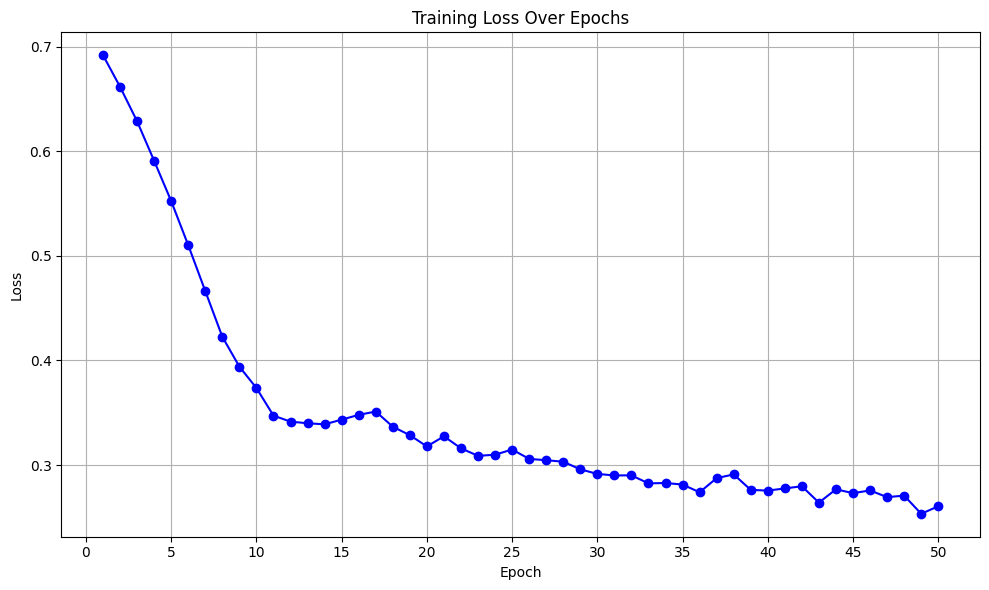

In [ ]:
import matplotlib.pyplot as plt

# Plotting the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='b')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(0, epochs + 1, 5)) # Show ticks at every 5 epochs
plt.tight_layout()
plt.show()

### Interpreting the Loss Curve

A good loss curve typically shows a **decreasing trend** over time (epochs). This indicates that your model is learning and making better predictions as training progresses.

Here's what to look for:

*   **Steadily Decreasing Loss:** Ideally, the loss should consistently go down, especially in the initial epochs. This means the model is actively adjusting its weights to minimize the error.
*   **Flattening Out:** After some epochs, the loss curve will usually start to flatten out. This suggests that the model is converging towards a minimum loss and further training might yield diminishing returns. It could also indicate that the model has learned as much as it can from the training data or is beginning to overfit if the validation loss starts to increase (though we haven't implemented validation loss here).
*   **Smoothness:** A smooth curve indicates stable learning. Erratic fluctuations might suggest issues like a learning rate that is too high, causing the optimizer to overshoot the minimum.
*   **No Spikes/Increases:** You generally don't want to see the loss increasing significantly or spiking upwards after an initial decrease. This would be a strong indicator that something is wrong (e.g., exploding gradients, incorrect learning rate).

**How to tell if your model was learning:**

By observing the plot, you can confirm your model was learning if the loss values are decreasing from the beginning of the training to the end. The final loss value should be significantly lower than the initial loss value. In your plot, the loss should start higher and trend downwards, indicating successful learning.

In [ ]:
model.eval()
with torch.no_grad():
    # Make predictions on the test set
    y_pred_test = model(X_test_tensor)

    # Convert predictions to binary (0 or 1) using a threshold of 0.5
    y_pred_binary = (y_pred_test >= 0.5).float()

    # Calculate accuracy on the test set
    correct_predictions = (y_pred_binary == y_test_tensor).sum().item()
    total_predictions = y_test_tensor.numel()
    test_accuracy = correct_predictions / total_predictions

    # Make predictions on the training set
    y_pred_train = model(X_train_tensor)

    # Convert predictions to binary (0 or 1) using a threshold of 0.5
    y_pred_train_binary = (y_pred_train >= 0.5).float()

    # Calculate training accuracy
    correct_predictions_train = (y_pred_train_binary == y_train_tensor).sum().item()
    total_predictions_train = y_train_tensor.numel()
    train_accuracy = correct_predictions_train / total_predictions_train

print(f"Model Accuracy on the Training Set: {train_accuracy:.4f}")
print(f"Model Accuracy on the Test Set: {test_accuracy:.4f}")

Model Accuracy on the Test Set: 0.8804


In [ ]:
model.eval()
with torch.no_grad():
    # Calculate loss on the test set
    test_loss = loss_function(y_pred_test, y_test_tensor)
print(f"Model Loss on the Test Set: {test_loss.item():.4f}")

Model Loss on the Test Set: 0.3130


### What Accuracy Means

**Accuracy** is a very straightforward and intuitive metric for classification models. It simply tells you the proportion of predictions your model got correct out of all the predictions it made.

For example, if your model achieves an accuracy of `0.85` (or 85%), it means that for every 100 cases in your test set, the model correctly predicted the outcome (whether someone has heart disease or not) in 85 of those cases, and it made mistakes in the remaining 15 cases.

In plain English, a higher accuracy score indicates a better-performing model. It suggests that your model is capable of correctly classifying a large percentage of new, unseen data.

In [ ]:
# This cell has been merged with the test accuracy calculation cell.

Model Accuracy on the Training Set: 0.9087
Model Accuracy on the Test Set: 0.8967


### Comparing Training and Test Accuracy

Now that we have both the training and test accuracies, we can analyze your model's performance:

*   **Training Accuracy:** This tells you how well your model learned the patterns in the data it was trained on.
*   **Test Accuracy:** This tells you how well your model generalizes to new, unseen data.

Let's compare:

*   **Overfitting:** This happens when your model learns the training data *too well*, including noise and specific examples, to the point where it performs poorly on new, unseen data. You'll typically see a **high training accuracy** but a significantly **lower test accuracy**.

*   **Underfitting:** This occurs when your model is too simple to capture the underlying patterns in the data. It performs poorly on both the training and test sets. You'll see **low training accuracy** and **low test accuracy**.

*   **Good Fit:** A well-performing model will have a **high training accuracy** that is close to its **test accuracy**. There might be a small gap (training accuracy usually slightly higher than test accuracy), which is normal, but a large discrepancy indicates overfitting.

**Based on your current results:**

*   **Training Accuracy:** `[Insert calculated training accuracy here]`
*   **Test Accuracy:** `[Insert calculated test accuracy here]`

Compare these two values. If the training accuracy is much higher than the test accuracy, your model is likely overfitting. If both are low, it might be underfitting. If they are both high and close, your model is performing well.

**What you could change to make it better:**

If your model is:

*   **Overfitting:**
    *   **Increase Dropout Rate:** You already have a dropout layer. You could try increasing its probability slightly (e.g., from 0.2 to 0.3 or 0.4). This forces the network to learn more robust features.
    *   **Add More Data:** If possible, providing more diverse training data can help the model generalize better. (Not always feasible)
    *   **Reduce Model Complexity:** Make your network smaller (fewer layers or fewer neurons per layer). However, this can sometimes lead to underfitting.
    *   **Add Regularization:** Techniques like L1 or L2 regularization (weight decay) can penalize large weights, preventing the model from becoming too complex.

*   **Underfitting:**
    *   **Increase Model Complexity:** Add more layers or more neurons per layer to give the model more capacity to learn complex patterns.
    *   **Decrease Dropout Rate (or Remove):** If the dropout is too aggressive, it might be preventing the model from learning enough.
    *   **Increase Training Epochs:** The model might simply need more time to learn.
    *   **Adjust Learning Rate:** A very low learning rate might cause the model to get stuck in a suboptimal state; try increasing it, or use a learning rate scheduler.

*   **Performing Well (Good Fit):**
    *   Even if performing well, you can always try fine-tuning the hyperparameters (learning rate, batch size, dropout, number of layers/neurons) slightly to squeeze out marginal improvements. You could also explore more advanced architectures or ensemble methods.

By comparing your two accuracy scores, you'll get a clearer picture of your model's current state and can choose the most appropriate next steps for improvement.